# 02 - Exploratory Data Analysis (EDA)

ამ ნოუთბუქში ვიკვლევთ გაერთიანებულ dataset-ს შემდეგი მიზნებით:

1. **სამიზნე ცვლადის ანალიზი** - `market_value_in_eur` - ის განაწილება
2. **Missing values** - რომელი სვეტები გვჭირდება და რომელი არა
3. **Feature-ების კორელაცია** - რომელი სტატისტიკაა ყველაზე მეტად კავშირში ფასთან
4. **პოზიციების ანალიზი** - მცველი vs თავდამსხმელი
5. **ასაკის გავლენა** - როდის აღწევს მოთამაშე ღირებულების პიკს
6. **ლიგების შედარება** - Premier League vs დანარჩენი

## 1. იმპორტები და კონფიგურაცია

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/merged_raw.csv')
print(f"Shape: {df.shape[0]:,} players × {df.shape[1]} features")

Shape: 2,111 players × 277 features


## 2. სამიზნე ცვლადის განაწილება

საბაზრო ღირებულება (`market_value_in_eur`) ძლიერ მარჯვნივ გადახრილია (right-skewed) - რამდენიმე სუპერვარსკვლავი ათეულობით მილიონი ღირს, უმეტესობა კი გაცილებით ნაკლები. ამიტომ მოდელირებისთვის **log-ტრანსფორმაციას** გამოვიყენებთ.

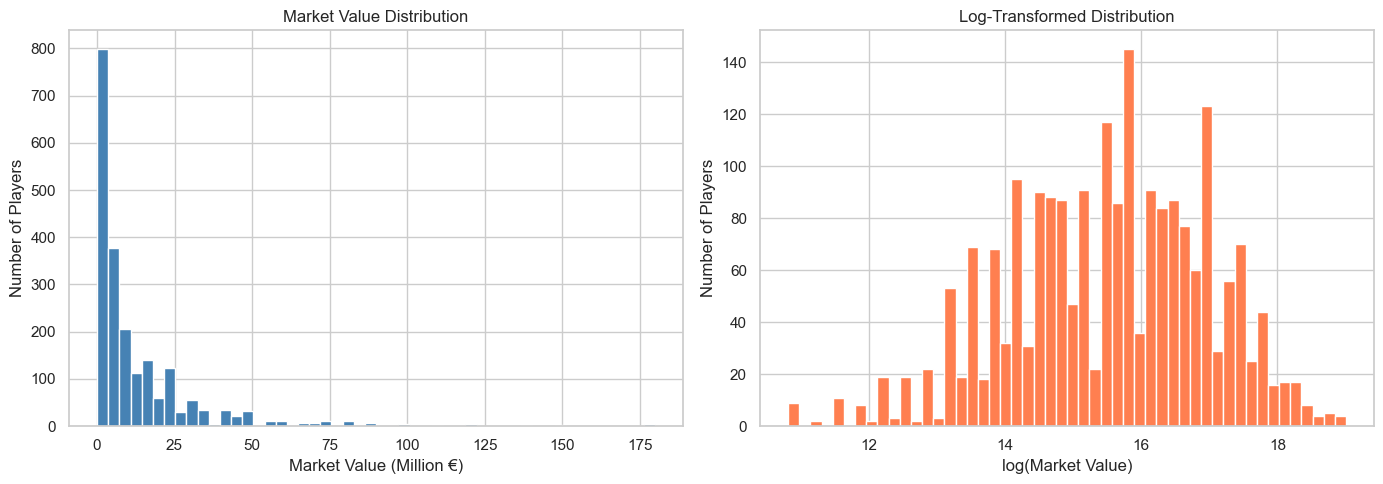

Skewness (original) : 3.55
Skewness (log)      : -0.35


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['market_value_in_eur'] / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Market Value Distribution')
axes[0].set_xlabel('Market Value (Million €)')
axes[0].set_ylabel('Number of Players')

df['log_market_value'] = np.log1p(df['market_value_in_eur'])
axes[1].hist(df['log_market_value'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(Market Value)')
axes[1].set_ylabel('Number of Players')

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness (original) : {df['market_value_in_eur'].skew():.2f}")
print(f"Skewness (log)      : {df['log_market_value'].skew():.2f}")

## 3. Missing Values - გამოტოვებული მონაცემები

277 სვეტიდან ბევრს შეიძლება ჰქონდეს ბევრი null. მხოლოდ იმ სვეტებს გამოვიყენებთ, სადაც გამოტოვება < 30%-ია.

Columns >30% missing: 53
Columns ≤30% missing: 225


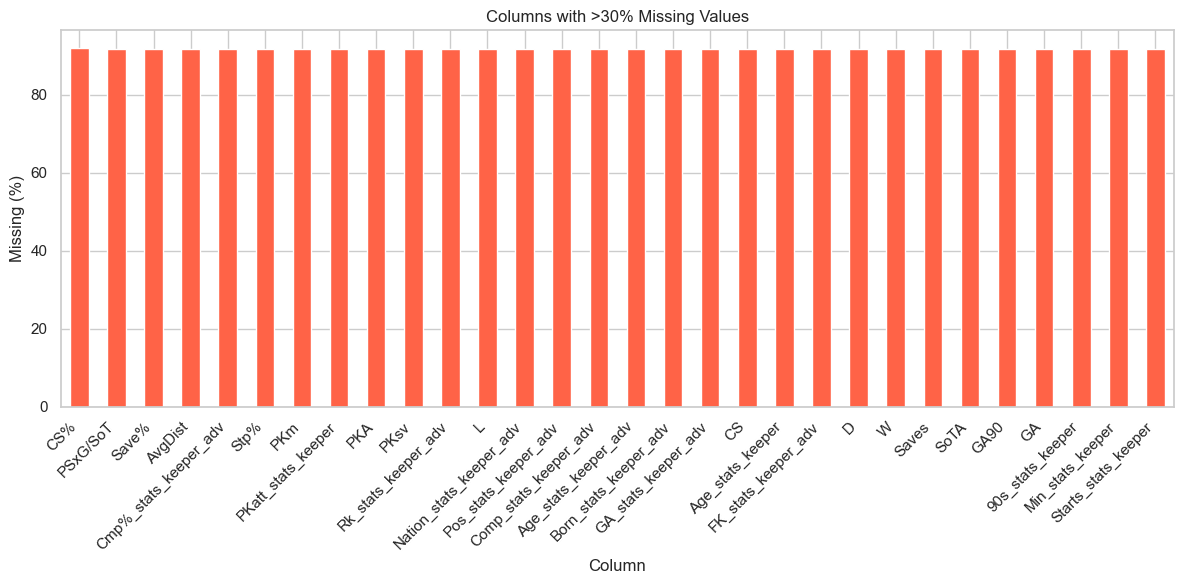

In [14]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(1)

high_missing = missing_pct[missing_pct > 30]
print(f"Columns >30% missing: {len(high_missing)}")
print(f"Columns ≤30% missing: {len(missing_pct) - len(high_missing)}")

if len(high_missing) > 0:
    plt.figure(figsize=(12, 6))
    high_missing.head(30).plot(kind='bar', color='tomato')
    plt.title('Columns with >30% Missing Values')
    plt.xlabel('Column')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../data/processed/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. ძირითადი Feature-ების კორელაცია სამიზნე ცვლადთან

ვირჩევთ ყველაზე მნიშვნელოვან სტატისტიკურ სვეტებს და ვამოწმებთ კორელაციას საბაზრო ღირებულებასთან.

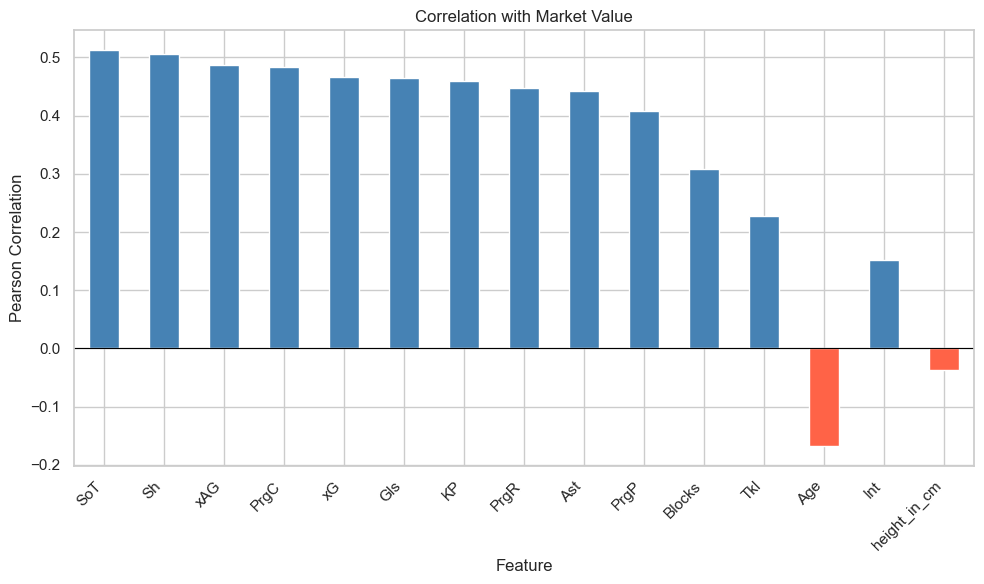

Correlation with market_value_in_eur:
SoT             0.513
Sh              0.507
xAG             0.488
PrgC            0.483
xG              0.467
Gls             0.465
KP              0.460
PrgR            0.447
Ast             0.443
PrgP            0.407
Blocks          0.309
Tkl             0.228
Age            -0.168
Int             0.153
height_in_cm   -0.037


In [15]:
key_features = [
    'Age', 'height_in_cm',
    'Gls', 'Ast', 'xG', 'xAG',
    'Sh', 'SoT', 'KP', 'PrgP', 'PrgC', 'PrgR',
    'Tkl', 'Int', 'Blocks',
    'market_value_in_eur'
]

available = [c for c in key_features if c in df.columns]
df_corr = df[available].copy()

corr = df_corr.corr()
mv_corr = corr['market_value_in_eur'].drop('market_value_in_eur').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in mv_corr]
mv_corr.plot(kind='bar', color=colors)
plt.title('Correlation with Market Value')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with market_value_in_eur:")
print(mv_corr.round(3).to_string())

## 5. ასაკის გავლენა საბაზრო ღირებულებაზე

ფეხბურთელის ღირებულება ასაკთან ერთად იზრდება პიკამდე (დაახლოებით 23-27 წელი), შემდეგ კი ეცემა.

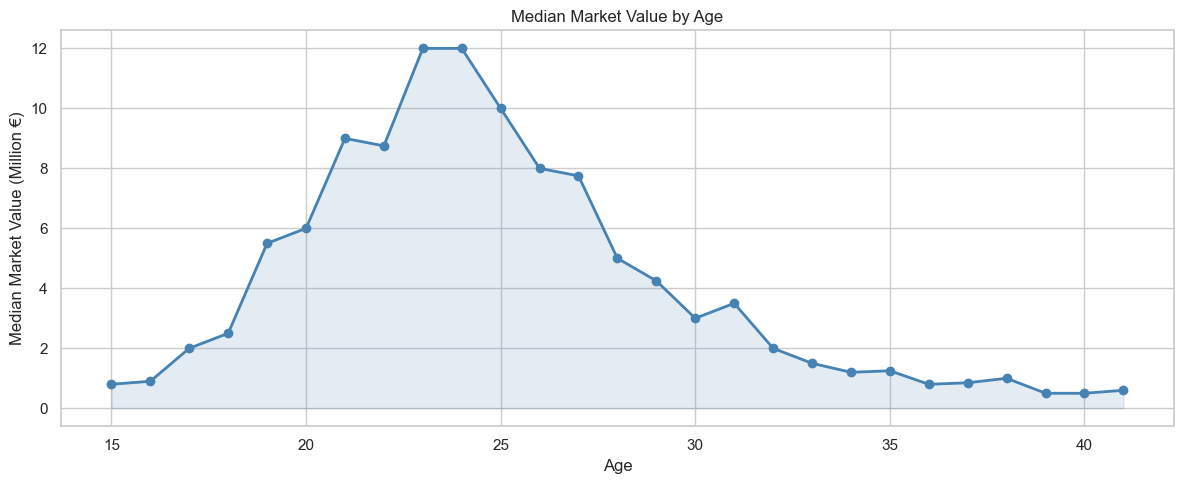

Peak value age  : 23.0 years
Peak median value: €12.0M


In [16]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
age_val = df.groupby('Age')['market_value_in_eur'].median() / 1e6

plt.figure(figsize=(12, 5))
plt.plot(age_val.index, age_val.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(age_val.index, age_val.values, alpha=0.15, color='steelblue')
plt.title('Median Market Value by Age')
plt.xlabel('Age')
plt.ylabel('Median Market Value (Million €)')
plt.tight_layout()
plt.savefig('../data/processed/age_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

peak_age = age_val.idxmax()
print(f"Peak value age  : {peak_age} years")
print(f"Peak median value: €{age_val.max():.1f}M")

## 6. პოზიციების ანალიზი

სხვადასხვა პოზიციის მოთამაშეებს განსხვავებული საბაზრო ღირებულება აქვთ.

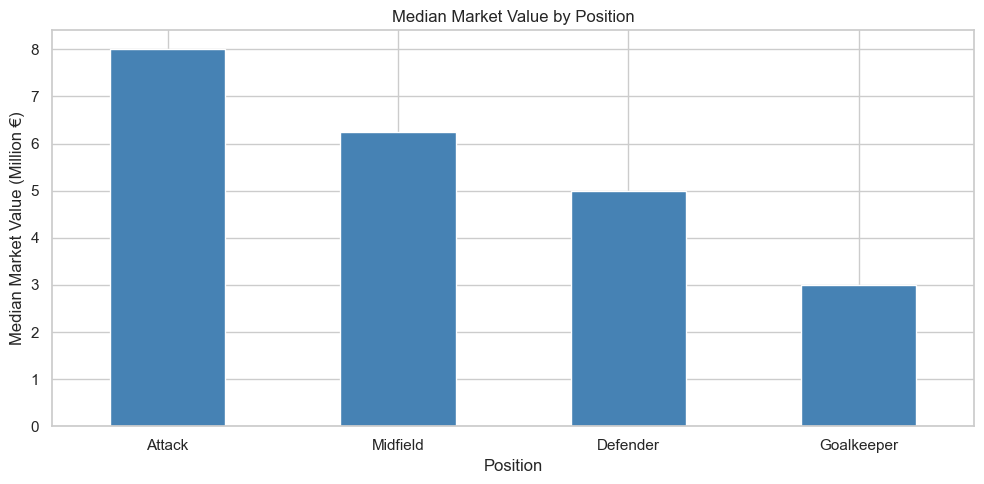

position
Attack        8.0
Midfield      6.2
Defender      5.0
Goalkeeper    3.0


In [19]:
pos_val = (df.groupby('position')['market_value_in_eur']
             .median()
             .sort_values(ascending=False) / 1e6)

plt.figure(figsize=(10, 5))
pos_val.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Median Market Value by Position')
plt.xlabel('Position')
plt.ylabel('Median Market Value (Million €)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/position_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

print(pos_val.round(1).to_string())

## 7. ლიგების შედარება

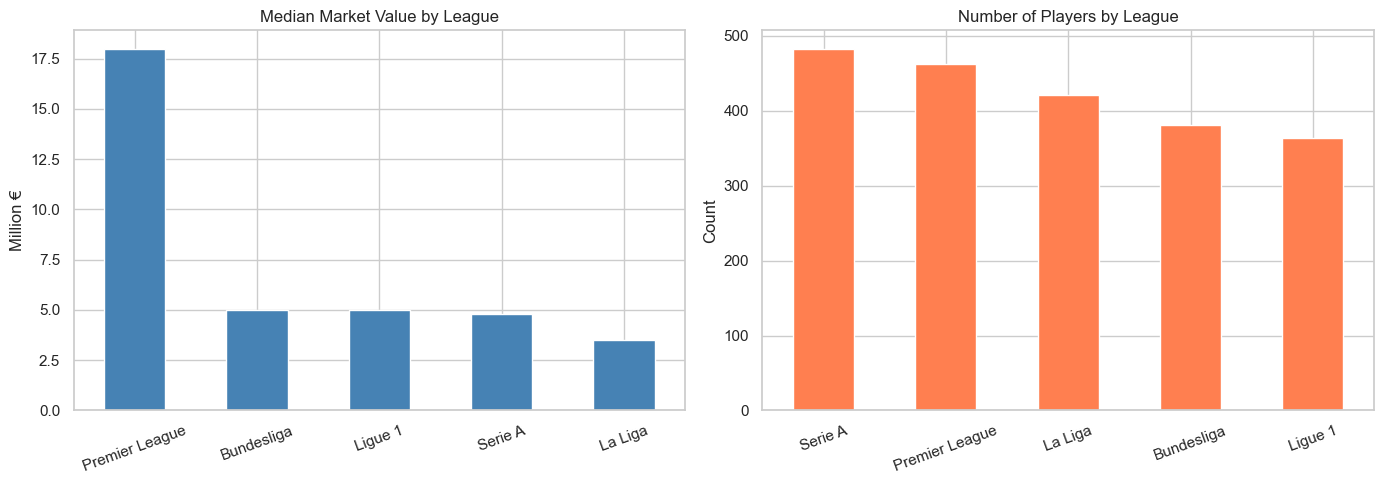

In [18]:
league_map = {
    'eng Premier League': 'Premier League',
    'es La Liga': 'La Liga',
    'de Bundesliga': 'Bundesliga',
    'it Serie A': 'Serie A',
    'fr Ligue 1': 'Ligue 1'
}
df['league'] = df['Comp'].map(league_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

league_val = (df.groupby('league')['market_value_in_eur']
                .median()
                .sort_values(ascending=False) / 1e6)
league_val.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median Market Value by League')
axes[0].set_xlabel('')
axes[0].set_ylabel('Million €')
axes[0].tick_params(axis='x', rotation=20)

df['league'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Number of Players by League')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/processed/league_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. შედეგების შეჯამება - EDA-ის მთავარი დასკვნები

### 1. სამიზნე ცვლადის განაწილება
- საბაზრო ღირებულება ძლიერ მარჯვნივგადახრილია - მოთამაშეების უმეტესობა
  1M – 25M შორის ფასდება, ხოლო რამდენიმე სუპერვარსკვლავი 100M-ს აღემატება
- Log-ტრანსფორმაცია განაწილებას მნიშვნელოვნად ანორმალიზებს
- **დასკვნა:** მოდელირებისთვის log(market_value) გამოვიყენებთ სამიზნე ცვლადად

### 2. Feature-ების კორელაცია სამიზნე ცვლადთან
- ყველაზე მაღალი კორელაცია: SoT (0.51), Sh (0.51), xAG (0.49), PrgC (0.48), xG (0.46)
- თავდასხმითი და პროგრესული სტატისტიკა დომინირებს - ბაზარი გოლებს და ასისტებს ყველაზე ძვირად აფასებს
- ასაკს უარყოფითი კორელაცია აქვს (-0.18) - ახალგაზრდა მოთამაშეები უფრო ძვირია
- სიმაღლე თითქმის არ მოქმედებს ღირებულებაზე (-0.04)
- **დასკვნა:** დარტყმები, პროგრესული მოქმედებები და expected stats ყველაზე მეტად გავლენიანი feature-ებია

### 3. ასაკის გავლენა საბაზრო ღირებულებაზე
- ღირებულება პიკს 23–24 წლის ასაკში აღწევს (12M მედიანა)
- 15 წლიდან 23 წლამდე სწრაფად იზრდება, შემდეგ თანდათანობით ეცემა
- 30 წლის ასაკში მცირე ზრდა შეინიშნება (გამოცდილი ელიტური მოთამაშეები)
- კავშირი არაწრფივია - tree-based მოდელები უკეთ დაიჭერს ამ პატერნს
- **დასკვნა:** ასაკი არაწრფივ feature-ად უნდა განვიხილოთ

### 4. საბაზრო ღირებულება პოზიციის მიხედვით
- Attack: 8M > Midfield: 6.3M > Defender: 5M > Goalkeeper: 3M
- ბაზარი ყოველთვის უფრო ძვირად აფასებს თავდამსხმელებს
- **დასკვნა:** პოზიცია მნიშვნელოვანი კატეგორიული feature იქნება და OneHotEncoding გამოვიყენებთ

### 5. საბაზრო ღირებულება ლიგის მიხედვით
- Premier League-ის მედიანა (18M) სხვა ლიგებზე 3-4-ჯერ მაღალია (5M)
- ყველა ლიგა თანაბრადაა წარმოდგენილი dataset-ში (350–480 მოთამაშე)
- **დასკვნა:** ლიგა კრიტიკული feature-ია - Premier League-ში თამაში მნიშვნელოვნად
  ზრდის მოთამაშის ღირებულებას სტატისტიკისგან დამოუკიდებლად